# Task 1 — Why we visualize (Datasaurus)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.transforms import offset_copy
from pathlib import Path

DATA = Path("data")
CHARTS = Path("charts")
CHARTS.mkdir(exist_ok=True)

BLUE, ORANGE, AQUA, YELLOW, MAGENTA = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"
SERIES = [BLUE, ORANGE, AQUA, YELLOW, MAGENTA]
INK, INK_SOFT, INK_MUTED = "#0b0b0b", "#52514e", "#8a8985"
GRID, SURFACE, QUIET = "#e6e5e1", "#fcfcfb", "#cfceca"

plt.rcParams.update({
    "figure.figsize": (8, 4.5), "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": INK_SOFT, "axes.titlesize": 11,
    "axes.titlelocation": "left", "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True, "grid.color": GRID, "xtick.color": INK_SOFT, "ytick.color": INK_SOFT,
    "legend.frameon": False, "font.size": 10, "savefig.dpi": 150, "savefig.bbox": "tight",
})


def finish(fig, title, subtitle=None, note=None, name=None):
    fig.tight_layout()
    tr = lambda y: offset_copy(fig.transFigure, fig=fig, y=y, units="points")
    if subtitle:
        fig.text(0.01, 1, subtitle, va="bottom", fontsize=10, color=INK_SOFT, transform=tr(4))
    fig.text(0.01, 1, title, va="bottom", fontsize=14, fontweight="bold", color=INK,
             transform=tr(22 if subtitle else 6))
    if note:
        fig.text(0.01, 0, note, va="top", fontsize=9, color=INK_MUTED, transform=tr(-4))
    if name:
        fig.savefig(CHARTS / f"{name}.png", facecolor=SURFACE)
    plt.show()

In [2]:
df = pd.read_csv(DATA / "datasaurus.csv")
print(df.shape, "missing:", df.isna().sum().sum())
df["dataset"].value_counts()

(1846, 3) missing: 0


dataset
dino          142
away          142
h_lines       142
v_lines       142
x_shape       142
star          142
high_lines    142
dots          142
circle        142
bullseye      142
slant_up      142
slant_down    142
wide_lines    142
Name: count, dtype: int64

No missing values, 13 datasets with 142 points each, so nothing is excluded.

## 1. Summary statistics

In [3]:
summary = df.groupby("dataset").agg(
    n=("x", "size"),
    mean_x=("x", "mean"),
    mean_y=("y", "mean"),
    std_x=("x", "std"),
    std_y=("y", "std"),
)
summary["corr"] = df.groupby("dataset").apply(lambda g: g["x"].corr(g["y"]), include_groups=False)
summary.round(2)

,n,mean_x,mean_y,std_x,std_y,corr
dataset,,,,,,
away,142,54.27,47.83,16.77,26.94,-0.06
bullseye,142,54.27,47.83,16.77,26.94,-0.07
circle,142,54.27,47.84,16.76,26.93,-0.07
dino,142,54.26,47.83,16.77,26.94,-0.06
dots,142,54.26,47.84,16.77,26.93,-0.06
h_lines,142,54.26,47.83,16.77,26.94,-0.06
high_lines,142,54.27,47.84,16.77,26.94,-0.07
slant_down,142,54.27,47.84,16.77,26.94,-0.07
slant_up,142,54.27,47.83,16.77,26.94,-0.07


## 2. What the table says

All 13 rows are basically identical: mean x ≈ 54.26, mean y ≈ 47.83, sd x ≈ 16.77, sd y ≈ 26.93 and
correlation ≈ −0.06. If this table was all I had, I would say these are 13 samples of the same data —
a random cloud around (54, 48) with no relationship between x and y.

## 3. Plot all 13

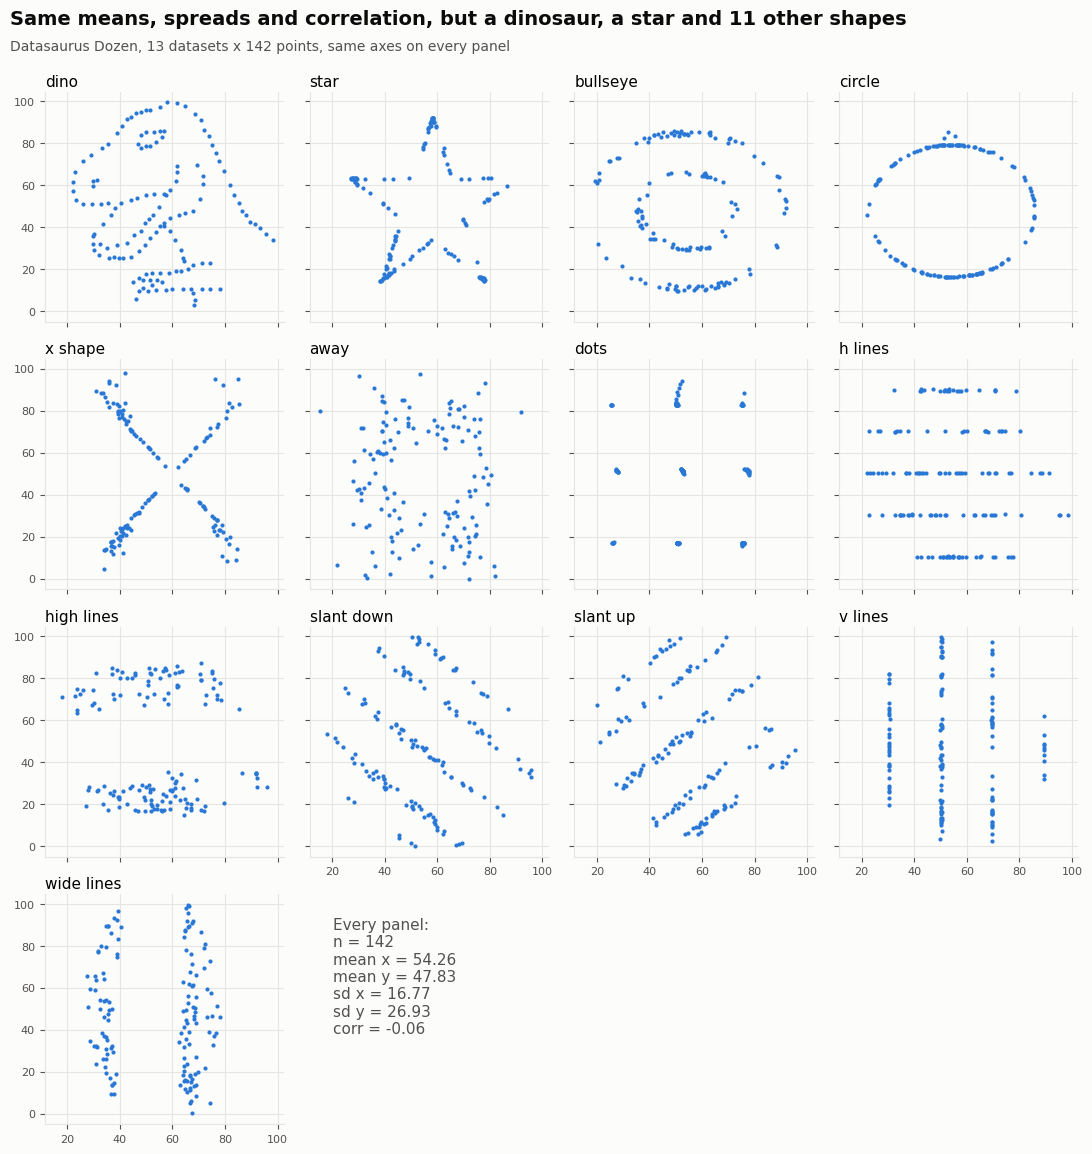

In [4]:
names = ["dino", "star", "bullseye", "circle", "x_shape"]
names += sorted(set(df["dataset"]) - set(names))

fig, axes = plt.subplots(4, 4, figsize=(11, 11), sharex=True, sharey=True)
for ax, name in zip(axes.flat, names):
    d = df[df["dataset"] == name]
    ax.scatter(d["x"], d["y"], s=9, color=BLUE, linewidth=0)
    ax.set_title(name.replace("_", " "), pad=4)
    ax.tick_params(labelsize=8)

for ax in axes.flat[13:]:
    ax.axis("off")
for ax in axes.flat[9:12]:
    ax.tick_params(labelbottom=True)
axes.flat[13].text(0.1, 0.9, "Every panel:\nn = 142\nmean x = 54.26\nmean y = 47.83\n"
                   "sd x = 16.77\nsd y = 26.93\ncorr = -0.06", va="top", color=INK_SOFT, fontsize=11,
                   transform=axes.flat[13].transAxes)

finish(fig, "Same means, spreads and correlation, but a dinosaur, a star and 11 other shapes",
       "Datasaurus Dozen, 13 datasets x 142 points, same axes on every panel",
       name="task1_datasaurus_grid")

**Why this chart:** x vs y is two numbers, so a scatter plot.  
Small multiples with shared axes, because 13 colours on one scatter would be unreadable.  
One colour only, since each panel title already names its dataset.

## 4. What I actually found

The datasets look nothing alike. There's a dinosaur, a star, a bullseye, a circle, an X, horizontal lines,
vertical lines, slanted lines, a grid of dots and so on. Some of them have very strong structure (points
sitting exactly on lines or rings) but the correlation still says −0.06, because correlation only measures
a straight-line relationship. The stats aren't wrong, they just can't see the shape.

## Does 13 datasets × 142 points make the stats more trustworthy?

No. More points makes the mean and correlation more *precise*, but they're still just a few numbers that
describe the centre, spread and linear trend. Everything else (clusters, curves, gaps) gets thrown away no
matter how big n is. If anything, more points makes it easier to fake: Anscombe had to design 11 points by
hand, while the Datasaurus was made by an algorithm moving points bit by bit into any shape while keeping
the stats the same. And having 13 tables that agree doesn't help, they're all missing the same information.
So same conclusion as Anscombe: plot the data first, then compute.